In [1]:
# This notebook runs our framework on Knapsack problems!

In [2]:
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
import random

from qiskit import transpile
from qiskit.circuit import Parameter,ParameterExpression
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit.converters import circuit_to_dag, dag_to_circuit
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeManilaV2,FakeNairobiV2,FakeMelbourneV2,FakeGuadalupeV2
import stim
from qiskit_optimization.applications import Knapsack
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit.circuit.library import QAOAAnsatz


import sys
sys.path.append("../")
from clapton.clapton import claptonize
from clapton.circuit_manipulation import transform_to_allowed_gates,qiskit_to_stim, modify_circuit, multi_angle_qaoa_circuit, generate_qiskit_param_map
from testing_scripts.graphs_utils import generate_random_complete_graph,generate_k_regular_graph

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [3]:
prob = Knapsack(values=[1, 2, 3], weights=[1, 2, 3], max_weight=4)
qp = prob.to_quadratic_program()
print(qp.prettyprint())

# intermediate QUBO form of the optimization problem
conv = QuadraticProgramToQubo()
qubo = conv.convert(qp)

# qubit Hamiltonian and offset
op, offset = qubo.to_ising()
print(f"num qubits: {op.num_qubits}, offset: {offset}\n")
print(op)

cost_hamiltonian = op
paulis,coeffs = cost_hamiltonian.paulis.to_labels(),cost_hamiltonian.coeffs.real
reversed_paulis = [p[::-1] for p in paulis]

Problem name: Knapsack

Maximize
  x_0 + 2*x_1 + 3*x_2

Subject to
  Linear constraints (1)
    x_0 + 2*x_1 + 3*x_2 <= 4  'c0'

  Binary variables (3)
    x_0 x_1 x_2

num qubits: 6, offset: 39.0

SparsePauliOp(['IIIIIZ', 'IIIIZI', 'IIIZII', 'IIZIII', 'IZIIII', 'ZIIIII', 'IIIIZZ', 'IIIZIZ', 'IIZIIZ', 'IZIIIZ', 'ZIIIIZ', 'IIIZZI', 'IIZIZI', 'IZIIZI', 'ZIIIZI', 'IIZZII', 'IZIZII', 'ZIIZII', 'IZZIII', 'ZIZIII', 'ZZIIII'],
              coeffs=[ -6.5+0.j, -13. +0.j, -19.5+0.j,  -7. +0.j, -14. +0.j,  -7. +0.j,
   7. +0.j,  10.5+0.j,   3.5+0.j,   7. +0.j,   3.5+0.j,  21. +0.j,
   7. +0.j,  14. +0.j,   7. +0.j,  10.5+0.j,  21. +0.j,  10.5+0.j,
   7. +0.j,   3.5+0.j,   7. +0.j])


In [4]:
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=1)

dec_circ = circuit.decompose().decompose()

In [5]:
dag = circuit_to_dag(dec_circ)
param_list = [(node.op.params) for node in dag.op_nodes() if node.op.params and isinstance(node.op.params[0], ParameterExpression)]
param_list

[[ParameterExpression(-13.0*γ[0])],
 [ParameterExpression(-26.0*γ[0])],
 [ParameterExpression(14.0*γ[0])],
 [ParameterExpression(-39.0*γ[0])],
 [ParameterExpression(21.0*γ[0])],
 [ParameterExpression(42.0*γ[0])],
 [ParameterExpression(-14.0*γ[0])],
 [ParameterExpression(7.0*γ[0])],
 [ParameterExpression(14.0*γ[0])],
 [ParameterExpression(21.0*γ[0])],
 [ParameterExpression(-28.0*γ[0])],
 [ParameterExpression(14.0*γ[0])],
 [ParameterExpression(28.0*γ[0])],
 [ParameterExpression(42.0*γ[0])],
 [ParameterExpression(14.0*γ[0])],
 [ParameterExpression(-14.0*γ[0])],
 [ParameterExpression(7.0*γ[0])],
 [ParameterExpression(2.0*β[0])],
 [ParameterExpression(14.0*γ[0])],
 [ParameterExpression(2.0*β[0])],
 [ParameterExpression(21.0*γ[0])],
 [ParameterExpression(2.0*β[0])],
 [ParameterExpression(7.0*γ[0])],
 [ParameterExpression(2.0*β[0])],
 [ParameterExpression(14.0*γ[0])],
 [ParameterExpression(2.0*β[0])],
 [ParameterExpression(2.0*β[0])]]

In [6]:
# Transform qiskit circ. to stim.
modified_circ = modify_circuit(dec_circ)
pcirc = transform_to_allowed_gates(modified_circ)

In [7]:
def parameter_renaming(dec_circ):
    dag = circuit_to_dag(dec_circ)
    gamma_counter, beta_counter = 0, 0
    angle_multipliers = {}
    for node in dag.op_nodes():
        if node.op.params and isinstance(node.op.params[0], ParameterExpression):
            param_name = list(node.op.params[0].parameters)[0].name 
            if "β" in param_name:

                multiplier = float(str(node.op.params[0]).split("*")[0])

                beta = Parameter(f'{multiplier}*beta_{beta_counter}')
                new_params = [beta if (isinstance(p, ParameterExpression)) else p for p in node.op.params]
                new_op = node.op.copy()
                new_op.params = new_params  # Create a modified version of the operation
                dag.substitute_node(node, new_op)  # Replace the node in the DAG
                beta_counter += 1

                angle_multipliers[beta.name] = multiplier
            

            elif "γ" in param_name:

                multiplier = float(str(node.op.params[0]).split("*")[0])
                
                gamma = Parameter(f'{multiplier}*gamma_{gamma_counter}')
                new_params = [gamma if (isinstance(p, ParameterExpression)) else p for p in node.op.params]
                new_op = node.op.copy()
                new_op.params = new_params  # Create a modified version of the operation
                dag.substitute_node(node, new_op)  # Replace the node in the DAG
                gamma_counter += 1

                angle_multipliers[gamma.name] = multiplier

    # Convert DAG back to a circuit
    new_qc = dag_to_circuit(dag)
    return new_qc, circuit_to_dag(new_qc) , angle_multipliers

# Usage
pcirc, dag , angle_multipliers= parameter_renaming(pcirc)

In [8]:
# # Transform qiskit circ. to stim.
# modified_circ = modify_circuit(dec_circ) #circuit
# pcirc = transform_to_allowed_gates(modified_circ)

stim_circ = qiskit_to_stim(pcirc)
stim_circ.stim_circuit().diagram()


q0: -S-SQRT_X-Z-I------------@---@------------@---@------------------@---@------------------------@---@------------------------------@---@-SQRT_X-I-SQRT_X-S-------------------------------------------------------------------------------------------------------------------
                             |   |            |   |                  |   |                        |   |                              |   |
q1: ------------S-SQRT_X-S-I-X-I-X------------|---|-@---@------------|---|-@---@------------------|---|-@---@------------------------|---|-----------------@---@-S-SQRT_X-I-SQRT_X-S-------------------------------------------------------------------------------------------
                                              |   | |   |            |   | |   |                  |   | |   |                        |   |                 |   |
q2: -----------------------------S-SQRT_X-S-I-X-I-X-X-I-X------------|---|-|---|-@---@------------|---|-|---|-@---@------------------|---|-----------------|---|-------------------@---@-S-SQRT_X-I-SQRT_X-S-------------------------------------------------------------------
                                                                     |   | |   | |   |            |   | |   | |   |                  |   |                 |   |                   |   |
q3: ----------------------------------------------------S-SQRT_X-S-I-X-I-X-X-I-X-X-I-X------------|---|-|---|-|---|-@---@------------|---|-----------------|---|-------------------|---|-------------------@---@-S-SQRT_X-I-SQRT_X-S-------------------------------------------
                                                                                                  |   | |   | |   | |   |            |   |                 |   |                   |   |                   |   |
q4: ---------------------------------------------------------------------------------S-SQRT_X-S-I-X-I-X-X-I-X-X-I-X-X-I-X------------|---|-----------------|---|-------------------|---|-------------------|---|-------------------@---@-S-SQRT_X-I-SQRT_X-S-------------------
                                                                                                                                     |   |                 |   |                   |   |                   |   |                   |   |
q5: --------------------------------------------------------------------------------------------------------------------S-SQRT_X-S-I-X-I-X-----------------X-I-X-------------------X-I-X-------------------X-I-X-------------------X-I-X-------------------S-SQRT_X-I-SQRT_X-S-

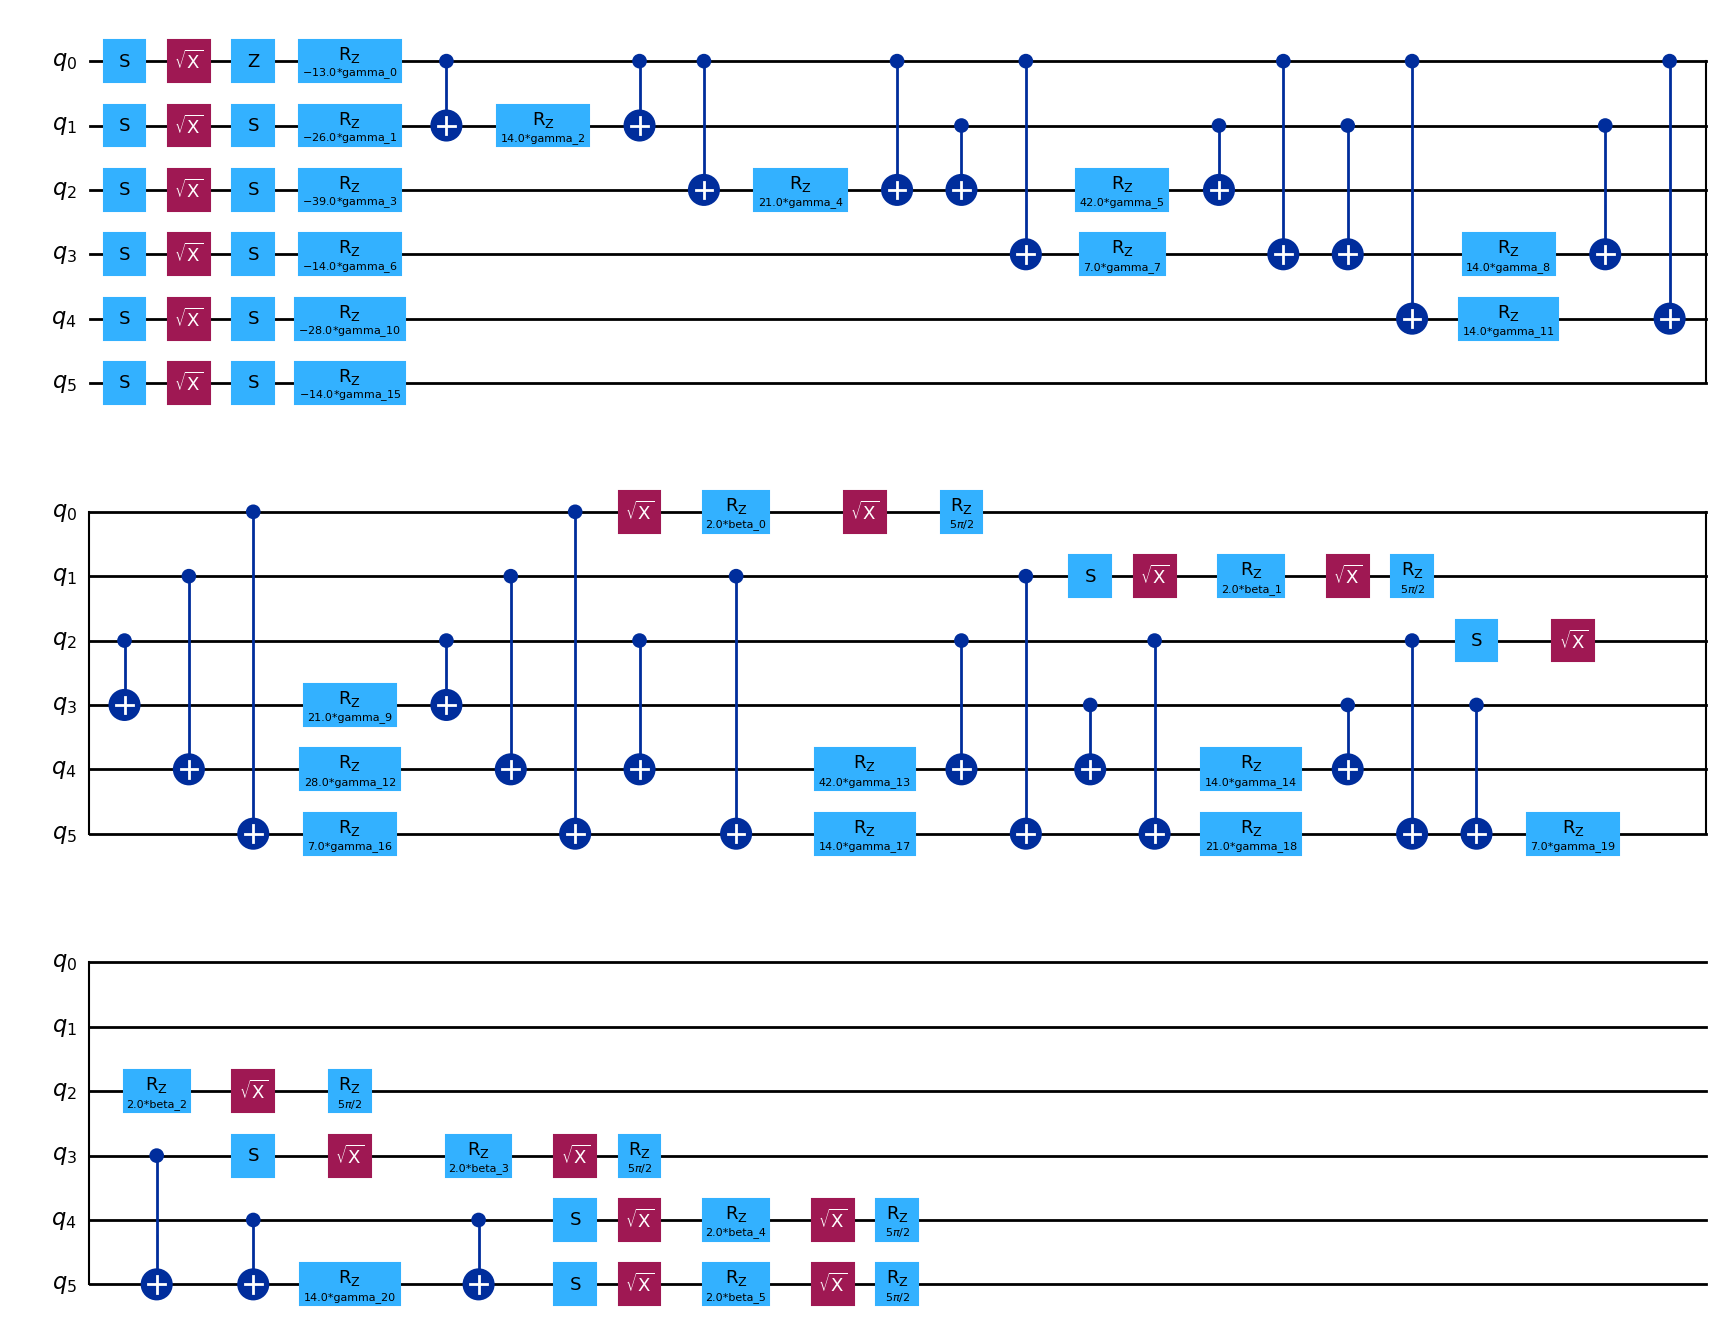

In [9]:
pcirc.draw('mpl')

In [10]:
param_map = generate_qiskit_param_map(pcirc)

In [11]:
stim_circ.define_parameter_map(param_map)

In [12]:
ks_best = []
random.seed(7) #7
for i in range(pcirc.num_parameters):
    ks_best.append(random.randint(0, 3))
    
# ks_best = [1, 0, 0, 0, 0, 0, 0, 3, 0]*3
# ks_best = [0]*(pcirc.num_parameters)

# ks_best =[3, 2, 0, 0, 2, 2, 2, 0, 3, 0, 2, 2, 2, 2, 2, 0, 3, 3, 2, 0, 1, 2, 3, 3, 2, 3, 3]

stim_circ.assign(ks_best)

In [13]:
def stim_exp_val(stim_qc,paulis,coeffs):
    sim = stim.TableauSimulator()
    sim.do_circuit(stim_qc)
    pauli_expect = [sim.peek_observable_expectation(stim.PauliString(p)) for p in paulis] #need paulis
    loss = np.inner(coeffs, pauli_expect)
    return loss

stim_energy = stim_exp_val(stim_circ.stim_circuit(), reversed_paulis, coeffs)
print(stim_energy)


-14.0


In [14]:
def cafqa_params_energy(circuit, hamiltonian, parameters):
    estimator = Estimator(mode=AerSimulator(method='statevector'))
    isa_hamiltonian = hamiltonian.apply_layout(circuit.layout)

    pub = (circuit, isa_hamiltonian, parameters)
    job = estimator.run([pub])

    results = job.result()[0]
    return results.data.evs

In [15]:
pcirc.parameters

ParameterView([Parameter(-13.0*gamma_0), Parameter(-14.0*gamma_15), Parameter(-14.0*gamma_6), Parameter(-26.0*gamma_1), Parameter(-28.0*gamma_10), Parameter(-39.0*gamma_3), Parameter(14.0*gamma_11), Parameter(14.0*gamma_14), Parameter(14.0*gamma_17), Parameter(14.0*gamma_2), Parameter(14.0*gamma_20), Parameter(14.0*gamma_8), Parameter(2.0*beta_0), Parameter(2.0*beta_1), Parameter(2.0*beta_2), Parameter(2.0*beta_3), Parameter(2.0*beta_4), Parameter(2.0*beta_5), Parameter(21.0*gamma_18), Parameter(21.0*gamma_4), Parameter(21.0*gamma_9), Parameter(28.0*gamma_12), Parameter(42.0*gamma_13), Parameter(42.0*gamma_5), Parameter(7.0*gamma_16), Parameter(7.0*gamma_19), Parameter(7.0*gamma_7)])

In [16]:
angle_multipliers

{'-13.0*gamma_0': -13.0,
 '-26.0*gamma_1': -26.0,
 '14.0*gamma_2': 14.0,
 '-39.0*gamma_3': -39.0,
 '21.0*gamma_4': 21.0,
 '42.0*gamma_5': 42.0,
 '-14.0*gamma_6': -14.0,
 '7.0*gamma_7': 7.0,
 '14.0*gamma_8': 14.0,
 '21.0*gamma_9': 21.0,
 '-28.0*gamma_10': -28.0,
 '14.0*gamma_11': 14.0,
 '28.0*gamma_12': 28.0,
 '42.0*gamma_13': 42.0,
 '14.0*gamma_14': 14.0,
 '-14.0*gamma_15': -14.0,
 '7.0*gamma_16': 7.0,
 '2.0*beta_0': 2.0,
 '14.0*gamma_17': 14.0,
 '2.0*beta_1': 2.0,
 '21.0*gamma_18': 21.0,
 '2.0*beta_2': 2.0,
 '7.0*gamma_19': 7.0,
 '2.0*beta_3': 2.0,
 '14.0*gamma_20': 14.0,
 '2.0*beta_4': 2.0,
 '2.0*beta_5': 2.0}

In [17]:
ordered_params = [param.name for param in pcirc.parameters]
mults = [
    np.pi/ (2 * 1)  
    for param in ordered_params
]
cafqa_angles = [param * multiplier for param, multiplier in zip(ks_best, mults)]
cafqa_angles

[3.141592653589793,
 1.5707963267948966,
 4.71238898038469,
 0.0,
 0.0,
 0.0,
 3.141592653589793,
 0.0,
 1.5707963267948966,
 0.0,
 0.0,
 4.71238898038469,
 4.71238898038469,
 0.0,
 1.5707963267948966,
 0.0,
 4.71238898038469,
 0.0,
 0.0,
 1.5707963267948966,
 0.0,
 4.71238898038469,
 0.0,
 1.5707963267948966,
 0.0,
 1.5707963267948966,
 3.141592653589793]

In [ ]:
energies = [cafqa_params_energy(pcirc, cost_hamiltonian, cafqa_angles) for _ in range(10)]
average_energy = np.mean(energies)
print(f"Average Energy: {average_energy}")

Average Energy: -14.04870849609375


In [19]:
# assert stim_circ.internal_read() != ks_best

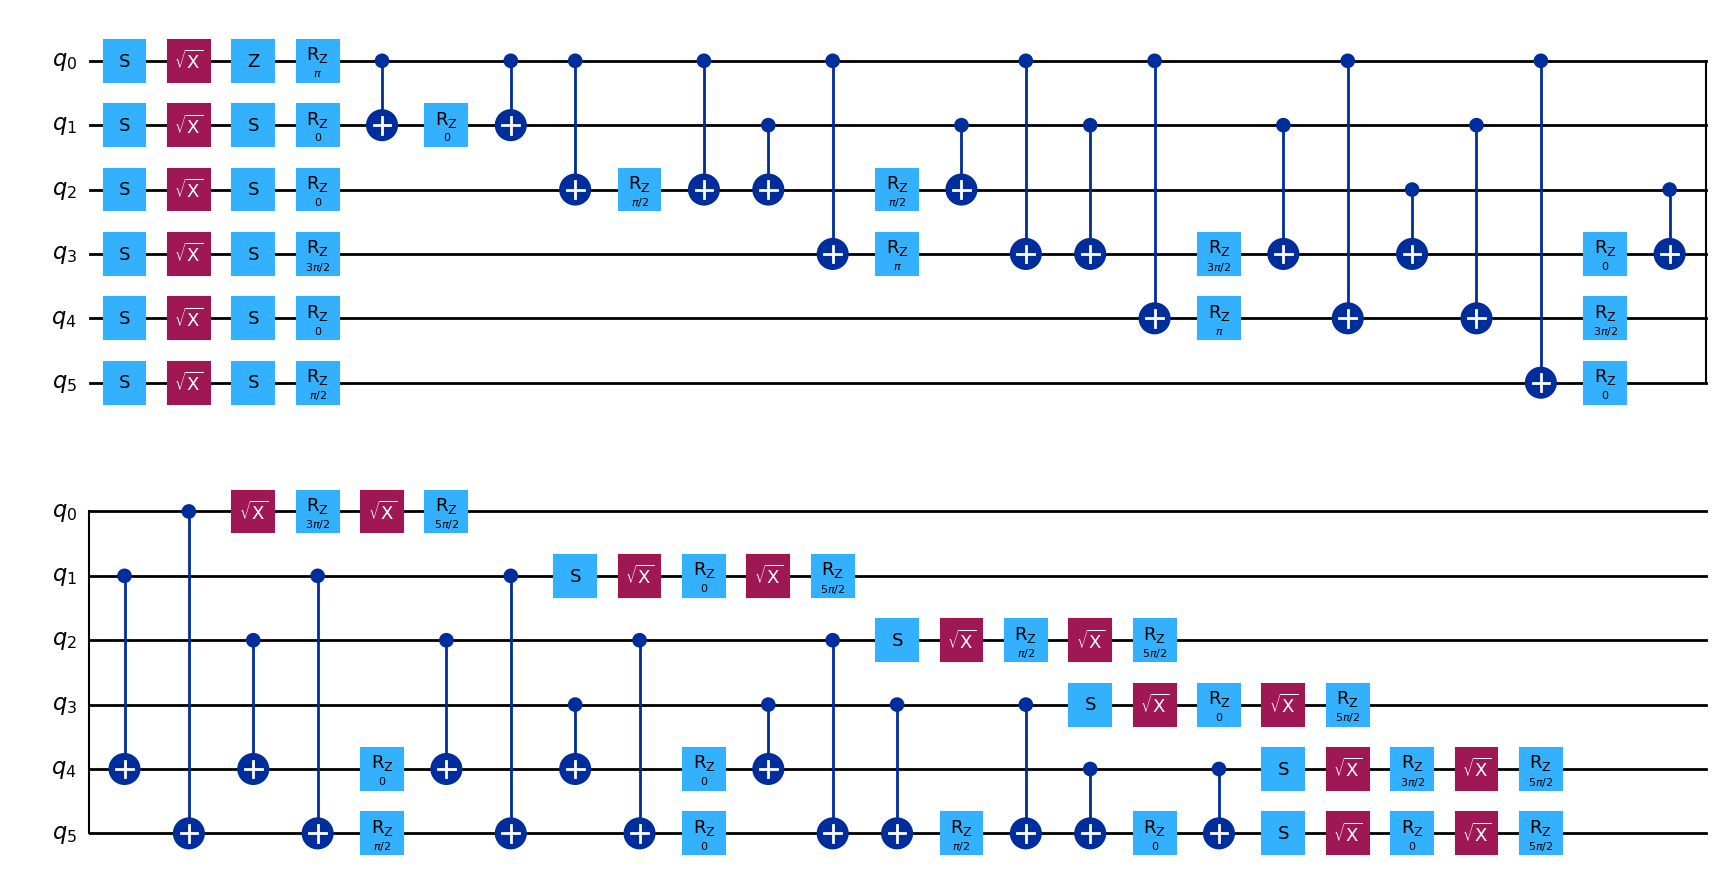

In [20]:
pcirc.assign_parameters(cafqa_angles).draw('mpl')

In [21]:
pcirc.parameters

ParameterView([Parameter(-13.0*gamma_0), Parameter(-14.0*gamma_15), Parameter(-14.0*gamma_6), Parameter(-26.0*gamma_1), Parameter(-28.0*gamma_10), Parameter(-39.0*gamma_3), Parameter(14.0*gamma_11), Parameter(14.0*gamma_14), Parameter(14.0*gamma_17), Parameter(14.0*gamma_2), Parameter(14.0*gamma_20), Parameter(14.0*gamma_8), Parameter(2.0*beta_0), Parameter(2.0*beta_1), Parameter(2.0*beta_2), Parameter(2.0*beta_3), Parameter(2.0*beta_4), Parameter(2.0*beta_5), Parameter(21.0*gamma_18), Parameter(21.0*gamma_4), Parameter(21.0*gamma_9), Parameter(28.0*gamma_12), Parameter(42.0*gamma_13), Parameter(42.0*gamma_5), Parameter(7.0*gamma_16), Parameter(7.0*gamma_19), Parameter(7.0*gamma_7)])

In [22]:
dag = circuit_to_dag(pcirc)
param_list = [(node.op.params)[0] for node in dag.op_nodes() if node.op.params and isinstance(node.op.params[0], ParameterExpression)]
param_list

[Parameter(-13.0*gamma_0),
 Parameter(-26.0*gamma_1),
 Parameter(14.0*gamma_2),
 Parameter(-39.0*gamma_3),
 Parameter(21.0*gamma_4),
 Parameter(42.0*gamma_5),
 Parameter(-14.0*gamma_6),
 Parameter(7.0*gamma_7),
 Parameter(14.0*gamma_8),
 Parameter(21.0*gamma_9),
 Parameter(-28.0*gamma_10),
 Parameter(14.0*gamma_11),
 Parameter(28.0*gamma_12),
 Parameter(42.0*gamma_13),
 Parameter(14.0*gamma_14),
 Parameter(-14.0*gamma_15),
 Parameter(7.0*gamma_16),
 Parameter(2.0*beta_0),
 Parameter(14.0*gamma_17),
 Parameter(2.0*beta_1),
 Parameter(21.0*gamma_18),
 Parameter(2.0*beta_2),
 Parameter(7.0*gamma_19),
 Parameter(2.0*beta_3),
 Parameter(14.0*gamma_20),
 Parameter(2.0*beta_4),
 Parameter(2.0*beta_5)]

In [23]:
def test_energy_functions(circuit, cost_hamiltonian, reversed_paulis, coeffs, tolerance=1, num_runs=10):
    for _ in range(num_runs):
        # Generate random parameters
        # random.seed(72) #7
        random_params = [random.randint(0, 3) for _ in range(circuit.num_parameters)]
        # stim_circ.define_parameter_map(param_map)
        
        # param_map = generate_qiskit_param_map(pcirc)

        ordered_params = [param.name for param in pcirc.parameters]
        mults = [
            (np.pi / (2 * 1)) 
            for param in ordered_params
        ]
        cafqa_angles = [param * multiplier for param, multiplier in zip(random_params, mults)]


        # Calculate energy using cafqa_params_energy
        cafqa_energy = np.mean([cafqa_params_energy(circuit, cost_hamiltonian, cafqa_angles) for _ in range(10)])
        # Assign parameters to stim circuit
        stim_circ.assign(random_params)
        
        # Calculate energy using stim_exp_val
        stim_energy = stim_exp_val(stim_circ.stim_circuit(), reversed_paulis, coeffs)
        
        # Check if the energies are close within the given tolerance
        # print(f"Random parameters used: {random_params}")
        assert np.isclose(cafqa_energy, stim_energy, atol=tolerance), f"Energy mismatch: cafqa_energy={cafqa_energy}, stim_energy={stim_energy}"
        if np.isclose(cafqa_energy, stim_energy, atol=tolerance):
            print(f"Matching energies: cafqa_energy={cafqa_energy}, stim_energy={stim_energy}")

    print(f"All {num_runs} runs passed within tolerance {tolerance}")

# Usage
test_energy_functions(pcirc, cost_hamiltonian, reversed_paulis, coeffs)

Matching energies: cafqa_energy=0.2105224609375, stim_energy=0.0
Matching energies: cafqa_energy=-0.0375, stim_energy=0.0
Matching energies: cafqa_energy=-0.0259033203125, stim_energy=0.0
Matching energies: cafqa_energy=0.25029296875, stim_energy=0.0
Matching energies: cafqa_energy=-0.1531494140625, stim_energy=0.0
Matching energies: cafqa_energy=0.234765625, stim_energy=0.0
Matching energies: cafqa_energy=6.668994140625, stim_energy=7.0
Matching energies: cafqa_energy=0.2533203125, stim_energy=0.0
Matching energies: cafqa_energy=-0.4935546875, stim_energy=0.0
Matching energies: cafqa_energy=0.075, stim_energy=0.0
All 10 runs passed within tolerance 1
